Saved v5.


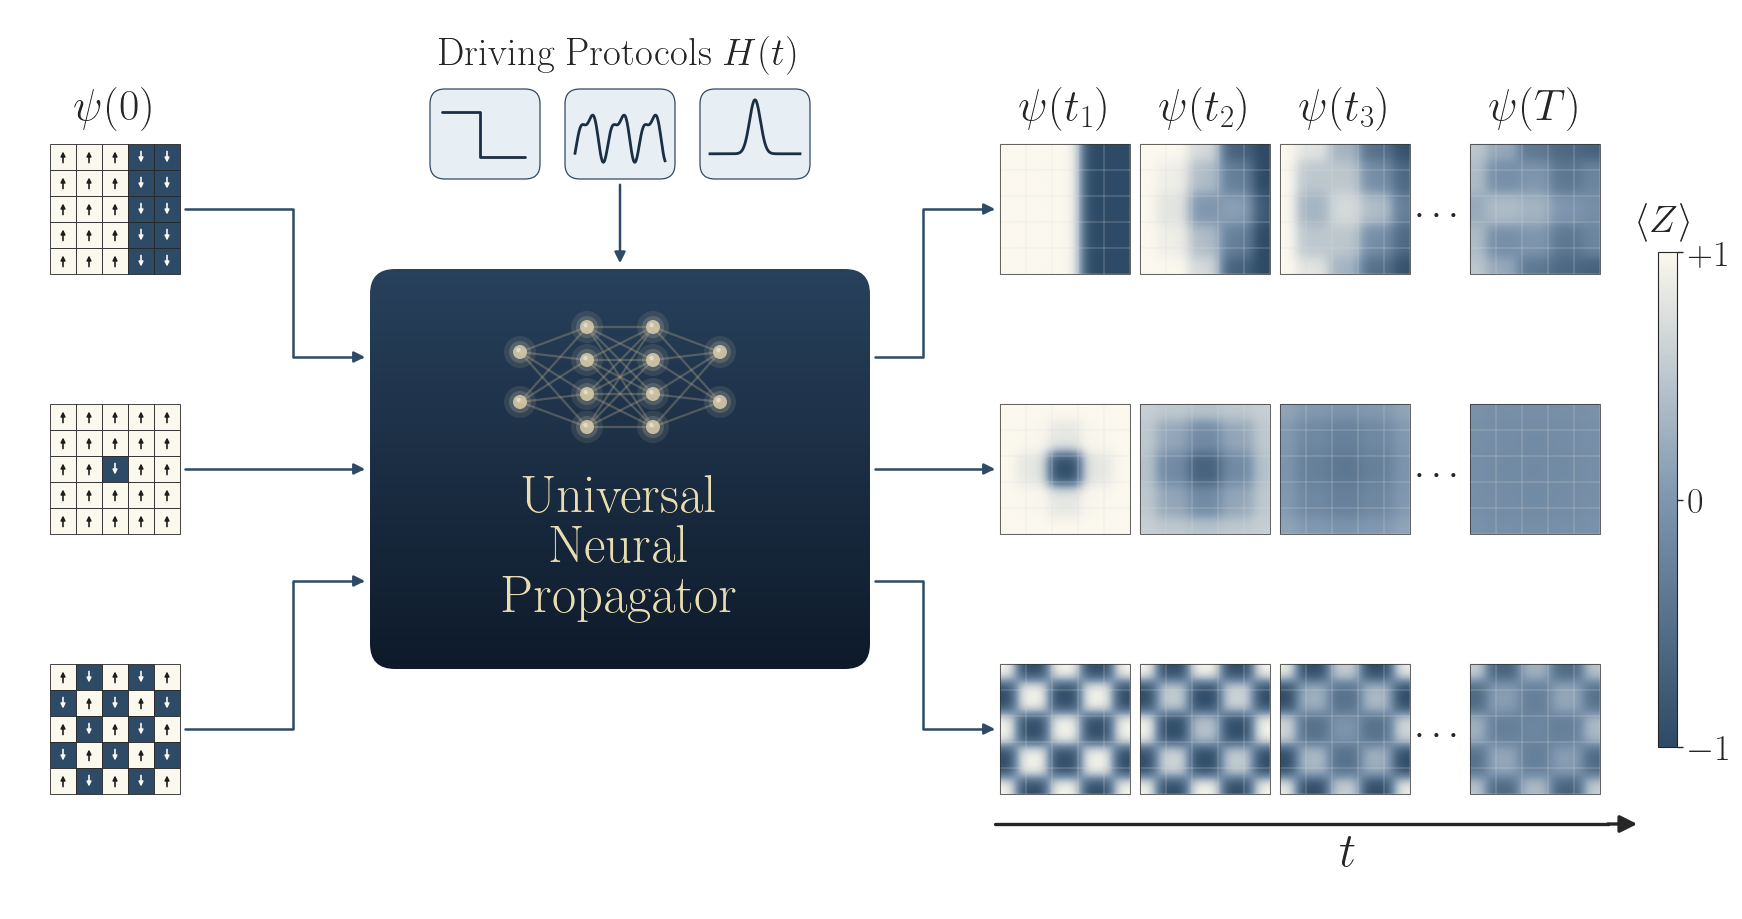

In [9]:
"""
UNQP cover figure v5.
Changes vs v4:
- Smooth curved L-shaped arrows (not straight diagonals)
- Three separate H(t) protocol boxes (step, sinusoid, ramp)
- Abstract neural-network sketch inside the central box
"""
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch, Circle
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap

mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
})

# ---------- Style ----------
BG          = '#FFFFFF'
WHITE_UP    = '#FBF8EE'
DARK_NAVY   = '#1A2E44'
DARK_BLUE   = '#2D4A66'
MID_BLUE    = '#7E96AE'
ARROW_DARK  = '#1F1F1F'
ARROW_LIGHT = '#FBF8EE'
ARROW_BTW   = '#2D4A66'
LINE        = '#262626'
CREAM       = '#E8DCB0'
GOLD        = '#A88758'
H_BOX_FILL  = '#E8EFF4'

cmap_div = LinearSegmentedColormap.from_list(
    'unqp_blue', [(0.0, WHITE_UP), (0.5, MID_BLUE), (1.0, DARK_BLUE)])


def smooth_field(arr5, n_dst=120, sigma=10.0):
    arr5 = np.asarray(arr5, dtype=float)
    src_pos = np.linspace(0, n_dst - 1, 5)
    yy, xx = np.meshgrid(np.arange(n_dst), np.arange(n_dst), indexing='ij')
    out = np.zeros((n_dst, n_dst))
    wt = np.zeros_like(out)
    for i in range(5):
        for j in range(5):
            w = np.exp(-((yy - src_pos[i])**2 + (xx - src_pos[j])**2) / (2*sigma**2))
            out += w * arr5[i, j]; wt += w
    return out / wt


fig = plt.figure(figsize=(16, 9), facecolor=BG)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 160); ax.set_ylim(0, 90)
ax.set_aspect('equal'); ax.axis('off'); ax.set_facecolor(BG)


def draw_arrow_in_cell(xc, yc, cell, direction, color):
    cx = xc + cell / 2
    if direction == 'up':
        ax.annotate('', xy=(cx, yc + cell*0.82), xytext=(cx, yc + cell*0.18),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, mutation_scale=6.5))
    elif direction == 'down':
        ax.annotate('', xy=(cx, yc + cell*0.18), xytext=(cx, yc + cell*0.82),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, mutation_scale=6.5))

def draw_initial_lattice(x0, y0, size, pattern):
    cell = size / 5
    for i in range(5):
        for j in range(5):
            xc, yc = x0 + j*cell, y0 + (4-i)*cell
            c, arr, ac = pattern[i][j]
            ax.add_patch(Rectangle((xc, yc), cell, cell, facecolor=c, edgecolor=LINE, lw=0.6))
            if arr: draw_arrow_in_cell(xc, yc, cell, arr, ac)

def draw_value_lattice(x0, y0, size, values):
    field = smooth_field(values, n_dst=120, sigma=10.0)
    ax.imshow(field, extent=[x0, x0+size, y0, y0+size], cmap=cmap_div,
              vmin=-1, vmax=1, aspect='auto', origin='upper', interpolation='bilinear', zorder=1)
    cell = size / 5
    for k in range(6):
        ax.plot([x0+k*cell]*2, [y0, y0+size], color='#DCDCDC', lw=0.25, zorder=2)
        ax.plot([x0, x0+size], [y0+k*cell]*2, color='#DCDCDC', lw=0.25, zorder=2)
    ax.add_patch(Rectangle((x0, y0), size, size, fc='none', ec=LINE, lw=0.5, zorder=3))


def draw_curved_arrow(x1, y1, x2, y2, depart_horizontal=True):
    """Arrow with straight segments and sharp 90-degree turns (H-V-H staircase)."""
    turn_frac = 0.6 if depart_horizontal else 0.4
    mid_x = x1 + (x2 - x1) * turn_frac
    if abs(y1 - y2) < 0.5:
        verts = [(x1, y1), (x2, y2)]
        codes = [Path.MOVETO, Path.LINETO]
    else:
        verts = [(x1, y1), (mid_x, y1), (mid_x, y2), (x2, y2)]
        codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO]
    path = Path(verts, codes)
    ax.add_patch(FancyArrowPatch(path=path, arrowstyle='-|>',
                                 mutation_scale=16, color=ARROW_BTW, lw=1.8))


# ============================================================
# Layout
# ============================================================
ROW_Y = [70, 44, 18]; LAT_SIZE = 13; INIT_X = 4
U_X, U_Y, U_W, U_H = 36, 24, 50, 40   # central box
OUT_X0 = 99; OUT_GAP = 1; DOT_GAP = 5
out_xs = [OUT_X0 + k*(LAT_SIZE+OUT_GAP) for k in range(3)]
out_xs.append(OUT_X0 + 3*(LAT_SIZE+OUT_GAP) + DOT_GAP)
DOT_X = OUT_X0 + 3*(LAT_SIZE+OUT_GAP) + DOT_GAP/2 - 0.5


# ============================================================
# Initial states
# ============================================================
W_CELL = (WHITE_UP, 'up', ARROW_DARK)
D_CELL = (DARK_BLUE, 'down', ARROW_LIGHT)
EXCIT  = (MID_BLUE, None, None)

psi1 = [[W_CELL if j < 3 else D_CELL for j in range(5)] for _ in range(5)]
psi2 = [[W_CELL]*5 for _ in range(5)]; psi2[2][2] = D_CELL
psi3 = [[W_CELL if (i+j) % 2 == 0 else D_CELL for j in range(5)] for i in range(5)]

for psi, yc in zip([psi1, psi2, psi3], ROW_Y):
    draw_initial_lattice(INIT_X, yc - LAT_SIZE/2, LAT_SIZE, psi)

ax.text(INIT_X + LAT_SIZE/2, ROW_Y[0] + LAT_SIZE/2 + 1.4,
        r"$\psi(0)$", fontsize=32, ha='center', va='bottom', color=LINE)


# ============================================================
# Universal Neural Propagator (gradient + neural net icon)
# ============================================================
box_clip = FancyBboxPatch((U_X, U_Y), U_W, U_H,
                          boxstyle='round,pad=0,rounding_size=2.5',
                          facecolor='none', edgecolor='none', linewidth=0)
ax.add_patch(box_clip)

navy_grad = LinearSegmentedColormap.from_list('ng', ['#28415C', '#0E1A2A'])
grad_arr = np.linspace(0, 1, 256).reshape(-1, 1)
im = ax.imshow(grad_arr, extent=[U_X, U_X+U_W, U_Y, U_Y+U_H],
               cmap=navy_grad, origin='upper', aspect='auto',
               interpolation='bilinear', zorder=1)
im.set_clip_path(box_clip)


# --- Neural-network icon (layered architecture with glow) ---
ncx, ncy = U_X + U_W/2, U_Y + U_H*0.73
NODE_COL = '#D4C8A8'     # warm cream for nodes
EDGE_COL = '#B0A585'     # muted gold for edges
GLOW_COL = '#D4C8A8'     # glow halo
 
# 4-layer network: 2 → 4 → 4 → 2
layer_x = [ncx - 10, ncx - 3.3, ncx + 3.3, ncx + 10]
layer_ys = [
    [ncy + 2.5, ncy - 2.5],                           # input: 2
    [ncy + 5, ncy + 1.7, ncy - 1.7, ncy - 5],         # hidden1: 4
    [ncy + 5, ncy + 1.7, ncy - 1.7, ncy - 5],         # hidden2: 4
    [ncy + 2.5, ncy - 2.5],                           # output: 2
]
# Build flat node list and layer-to-layer edges
all_nodes = []
layer_idx = []  # start index of each layer
for lx, lys in zip(layer_x, layer_ys):
    layer_idx.append(len(all_nodes))
    for ly in lys:
        all_nodes.append((lx, ly))
layer_idx.append(len(all_nodes))
 
all_edges = []
for L in range(len(layer_x) - 1):
    for i in range(layer_idx[L], layer_idx[L+1]):
        for j in range(layer_idx[L+1], layer_idx[L+2]):
            all_edges.append((i, j))
 
# Draw edges (thin, semi-transparent)
for i, j in all_edges:
    ax.plot([all_nodes[i][0], all_nodes[j][0]],
            [all_nodes[i][1], all_nodes[j][1]],
            color=EDGE_COL, lw=1.6, alpha=0.35, zorder=4)
 
# Draw nodes with glow halo
for (nx, ny) in all_nodes:
    # Outer glow
    ax.add_patch(Circle((nx, ny), 1.6, facecolor=GLOW_COL, edgecolor='none', alpha=0.12, zorder=4.5))
    # Inner glow
    ax.add_patch(Circle((nx, ny), 1.1, facecolor=GLOW_COL, edgecolor='none', alpha=0.20, zorder=4.6))
    # Solid node
    ax.add_patch(Circle((nx, ny), 0.7, facecolor=NODE_COL, edgecolor='none', alpha=0.90, zorder=5))
    # Highlight dot (specular)
    ax.add_patch(Circle((nx-0.15, ny+0.2), 0.22, facecolor='#FFFFFF', edgecolor='none', alpha=0.45, zorder=5.1))

# --- Text ---
for dy, word in [(3, 'Universal'), (-2, 'Neural'), (-7, 'Propagator')]:
    ax.text(U_X + U_W/2, U_Y + U_H/2 + dy - 6, word,
            fontsize=38, ha='center', va='center', color=CREAM, style='italic', zorder=5)


# ============================================================
# H(t) — three separate protocol boxes
# ============================================================
h_bw, h_bh, h_gap = 11, 9, 2.5
h_total = 3*h_bw + 2*h_gap
h_cx = U_X + U_W/2
h_x0 = h_cx - h_total/2
h_y = U_Y + U_H + 9    # above the central box

h_boxes = [(h_x0 + k*(h_bw + h_gap), h_y) for k in range(3)]

for (bx, by) in h_boxes:
    ax.add_patch(FancyBboxPatch((bx, by), h_bw, h_bh,
                                boxstyle='round,pad=0,rounding_size=1.5',
                                facecolor=H_BOX_FILL, edgecolor=DARK_BLUE, lw=0.9))

# Step
bx, by = h_boxes[0]
ax.plot([bx+1.2, bx+h_bw*0.45, bx+h_bw*0.45, bx+h_bw-1.5],
        [by+h_bh*0.75, by+h_bh*0.75, by+h_bh*0.25, by+h_bh*0.25],
        color=DARK_NAVY, lw=2.0, solid_capstyle='round')

# Sinusoid
bx, by = h_boxes[1]
sx = np.linspace(bx+1, bx+h_bw-1, 200)
sy = by + h_bh/2 - h_bh*0.22*np.sin((sx - bx)*2.0) - h_bh * 0.1 * np.sin((sx - bx)*4.0-1.0)
ax.plot(sx, sy, color=DARK_NAVY, lw=2.0)

# Ramp
bx, by = h_boxes[2]
sx = np.linspace(bx+1, bx+h_bw-1, 200)
center = bx + h_bw / 2                      # center of the box
sigma = h_bw * 0.05                          # width ≈ 15% of box
sy = by + h_bh*0.28 + h_bh*0.6 * np.exp(-((sx - center)**2) / (2*sigma**2))
ax.plot(sx, sy, color=DARK_NAVY, lw=2.0)


# Label
ax.text(h_cx, h_y + h_bh + 1.5, r'Driving Protocols $H(t)$',
        fontsize=28, ha='center', va='bottom', color=LINE)

# H(t) → U(t)  (vertical arrow)
ax.annotate('', xy=(h_cx, U_Y + U_H + 0.3), xytext=(h_cx, h_y - 0.3),
            arrowprops=dict(arrowstyle='-|>', color=ARROW_BTW, lw=1.8, mutation_scale=16))


# ============================================================
# Curved arrows: inputs → U(t)
# ============================================================
u_entry = [U_Y + U_H*0.78, U_Y + U_H*0.50, U_Y + U_H*0.22]
for yc, uy in zip(ROW_Y, u_entry):
    draw_curved_arrow(INIT_X + LAT_SIZE + 0.5, yc, U_X - 0.5, uy,
                      depart_horizontal=True)


# ============================================================
# Output snapshots (data unchanged from v4)
# ============================================================
top_t1 = [[+1]*3+[-1]*2]*5
top_t2 = [[+1.0,+1.0,+0.7,-0.7,-1.0],[+1.0,+0.9,+0.4,-0.3,-1.0],
          [+1.0,+0.8,+0.0,+0.1,-0.8],[+1.0,+0.9,+0.4,-0.3,-1.0],
          [+1.0,+1.0,+0.7,-0.7,-1.0]]
top_t3 = [[+1.0,+0.8,+0.3,-0.5,-0.9],[+1.0,+0.5,+0.5,-0.1,-0.6],
          [+1.0,+0.3,+0.7,+0.4,-0.3],[+1.0,+0.5,+0.5,-0.1,-0.6],
          [+1.0,+0.8,+0.3,-0.5,-0.9]]
top_T  = [[+0.5,+0.2,-0.4,-0.6,-0.7],[+0.4,-0.1,+0.0,-0.4,-0.2],
          [+0.2,+0.4,+0.3,+0.0,-0.1],[+0.4,-0.1,+0.0,-0.4,-0.2],
          [+0.5,+0.2,-0.4,-0.6,-0.7]]

def gauss_5x5(w, pk, bs):
    return [[bs+(pk-bs)*np.exp(-((i-2)**2+(j-2)**2)/(2*w**2)) for j in range(5)] for i in range(5)]
mid_t1=gauss_5x5(0.45,+1,-1); mid_t2=gauss_5x5(0.95,+0.7,-0.6)
mid_t3=gauss_5x5(1.6,+0.4,-0.3); mid_T=gauss_5x5(2.8,+0.15,-0.1)

bot_t1=[[+1 if (i+j)%2==0 else -1 for j in range(5)] for i in range(5)]
bot_t2=[[+1,-1,+1,-1,+1],[-1,+.6,-1,+.7,-1],[+1,-1,+.5,-1,+1],[-1,+.7,-1,+.6,-1],[+1,-1,+1,-1,+1]]
bot_t3=[[+.9,-1,+.6,-1,+.9],[-1,+.3,-.5,+.4,-1],[+.7,-.5,0,-.5,+.7],[-1,+.4,-.5,+.3,-1],[+.9,-1,+.6,-1,+.9]]
bot_T=[[+.6,-.7,+.3,-.6,+.5],[-.6,+.1,-.3,+.2,-.5],[+.3,-.3,-.2,-.3,+.4],[-.5,+.2,-.3,+.1,-.6],[+.5,-.6,+.4,-.7,+.6]]

snap_top=[top_t1,top_t2,top_t3,top_T]; snap_mid=[mid_t1,mid_t2,mid_t3,mid_T]; snap_bot=[bot_t1,bot_t2,bot_t3,bot_T]
neg = lambda a: [[-v for v in r] for r in a]
snap_top = [neg(s) for s in snap_top]
snap_bot = [neg(s) for s in snap_bot]

for k in range(4):
    x = out_xs[k]
    draw_value_lattice(x, ROW_Y[0]-LAT_SIZE/2, LAT_SIZE, snap_top[k])
    draw_value_lattice(x, ROW_Y[1]-LAT_SIZE/2, LAT_SIZE, snap_mid[k])
    draw_value_lattice(x, ROW_Y[2]-LAT_SIZE/2, LAT_SIZE, snap_bot[k])

for k, lab in enumerate([r'$\psi(t_1)$', r'$\psi(t_2)$', r'$\psi(t_3)$', r'$\psi(T)$']):
    ax.text(out_xs[k]+LAT_SIZE/2, ROW_Y[0]+LAT_SIZE/2+1.4, lab,
            fontsize=32, ha='center', va='bottom', color=LINE)

for yc in ROW_Y:
    ax.text(DOT_X, yc, r'$\cdots$', fontsize=28, ha='center', va='center', color=LINE)


# ============================================================
# Curved arrows: U(t) → outputs
# ============================================================
for yc, uy in zip(ROW_Y, u_entry):
    draw_curved_arrow(U_X + U_W + 0.5, uy, OUT_X0 - 0.5, yc,
                      depart_horizontal=False)


# ============================================================
# Time axis
# ============================================================
axis_y = ROW_Y[2] - LAT_SIZE/2 - 3
axis_xs = OUT_X0 - 0.5
axis_xe = out_xs[-1] + LAT_SIZE - 1
ax.plot([axis_xs, axis_xe+2], [axis_y]*2, color=LINE, lw=2.4, solid_capstyle='round')
ax.annotate('', xy=(axis_xe+5, axis_y), xytext=(axis_xe+1.5, axis_y),
            arrowprops=dict(arrowstyle='-|>', color=LINE, lw=2.4, mutation_scale=26),
            annotation_clip=False)
ax.text(axis_xe-25, axis_y-3, r'$t$', fontsize=35, ha='left', va='center', color=LINE)


# ============================================================
# Colorbar for <Z>
# ============================================================
cbar_ax = fig.add_axes([1.03, 0.18, 0.012, 0.55])
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
cmap_div = LinearSegmentedColormap.from_list(
    'unqp_blue', [(0.0, DARK_BLUE), (0.5, MID_BLUE), (1.0, WHITE_UP)])
cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap_div, norm=norm, orientation='vertical')
cb.set_ticks([-1, 0, 1])
cb.set_ticklabels([r'$-1$', r'$0$', r'$+1$'])
cb.ax.tick_params(labelsize=26, length=4, width=1.0, color=LINE)
for label in cb.ax.get_yticklabels():
    label.set_color(LINE)
#cb.ax.set_ylabel(r'$\langle Z \rangle$', fontsize=24, color=LINE, rotation=0, labelpad=18, va='center')
cb.ax.set_title(r'$\langle Z \rangle$', fontsize=28, color=LINE, pad=15)
cb.outline.set_edgecolor(LINE)
cb.outline.set_linewidth(0.8)

#plt.savefig('/home/claude/unqp_v5.png', dpi=180, facecolor=BG, bbox_inches='tight', pad_inches=0.15)
print("Saved v5.")